# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# LOAD DATA

In [2]:
df = pd.read_csv("house_price.csv")

print("Shape Dataset :", df.shape)

df.head()

Shape Dataset : (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# DATA UNDERSTANDING

In [3]:
print(df.info())

print("\nJumlah Missing Value:")
print(df.isnull().sum().sum())

print("\nJumlah Duplikat:")
print(df.duplicated().sum())

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [4]:
print(df.dtypes.value_counts())

object     43
int64      35
float64     3
Name: count, dtype: int64


# DATA CLEANING

In [5]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# OUTLIER REMOVAL

In [6]:
Q1 = df['SalePrice'].quantile(0.25)

Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df = df[
    (df['SalePrice'] >= lower)
    &
    (df['SalePrice'] <= upper)
]

print("Shape setelah Outlier Removal:")
print(df.shape)

Shape setelah Outlier Removal:
(1399, 81)


# EDA

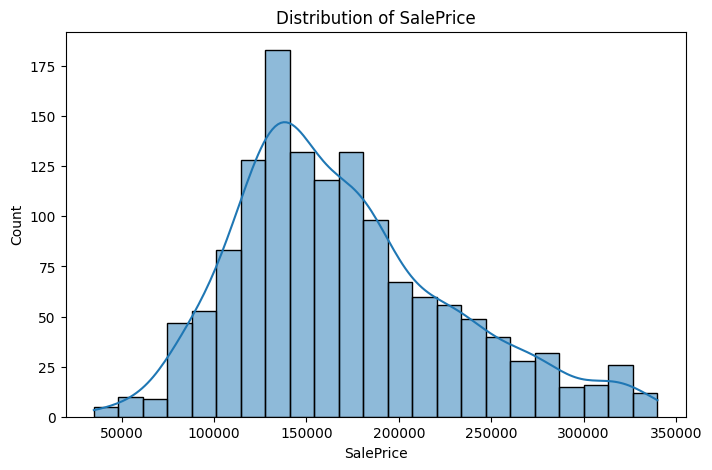

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['SalePrice'],
    kde=True
)

plt.title("Distribution of SalePrice")

plt.savefig(
    "distribution_saleprice.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

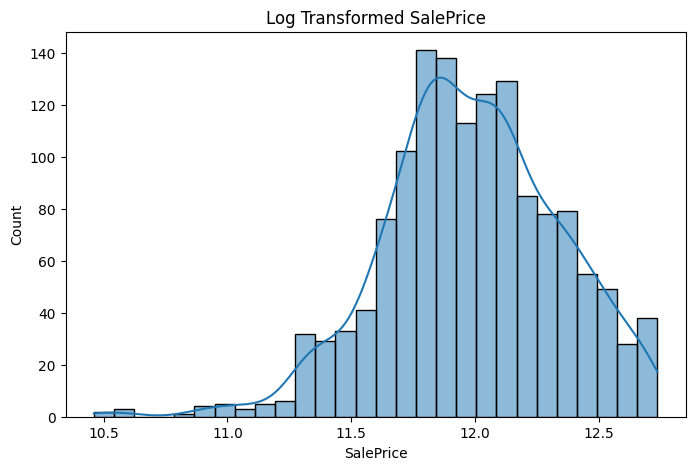

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df['SalePrice']),
    kde=True
)

plt.title("Log Transformed SalePrice")

plt.savefig(
    "log_saleprice.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# FEATURE SELECTION

In [9]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd',
    'MasVnrArea',
    'Fireplaces',
    'LotArea',
    'BsmtFinSF1',
    '2ndFlrSF'
]

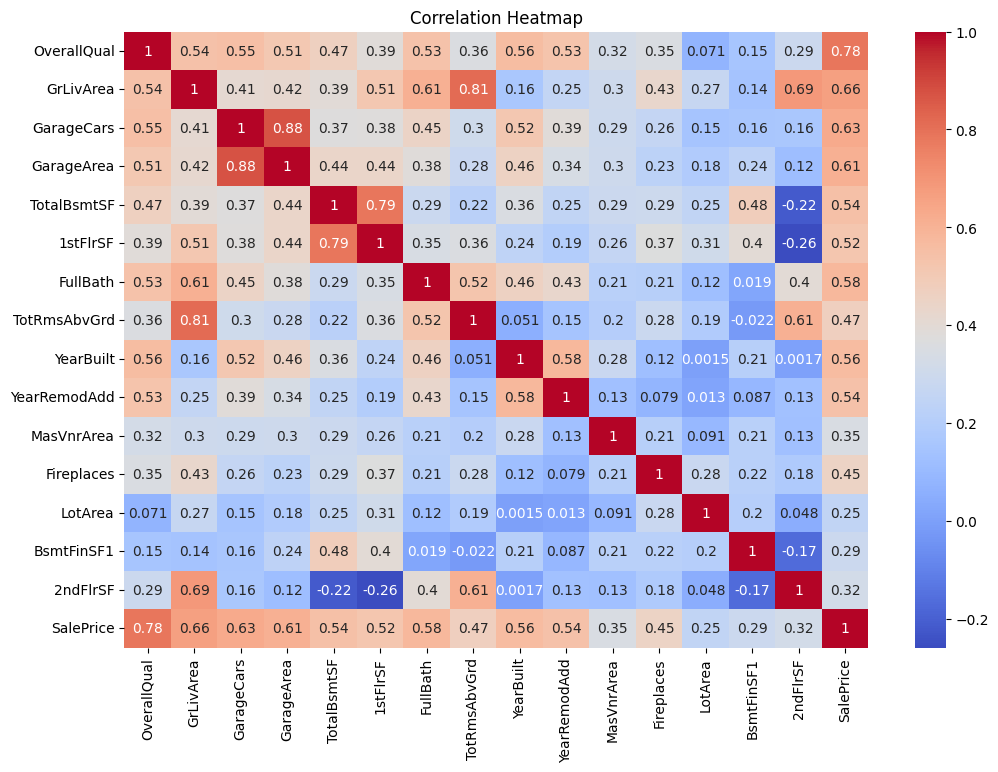

In [10]:
# correlation heatmap
selected_columns = features + ['SalePrice']

plt.figure(figsize=(12,8))

sns.heatmap(
    df[selected_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# FEATURE AND TARGET

In [11]:
X = df[features]

y = np.log1p(df['SalePrice'])

print("Jumlah Data :", X.shape[0])
print("Jumlah Fitur :", X.shape[1])

Jumlah Data : 1399
Jumlah Fitur : 15


In [12]:
corr_target = df[selected_columns].corr()['SalePrice']

corr_target.sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.784294
GrLivArea,0.661325
GarageCars,0.628013
GarageArea,0.607230
FullBath,0.577369
YearBuilt,0.564558
TotalBsmtSF,0.543508
YearRemodAdd,0.541161
1stFlrSF,0.522785


# TRAIN TEST SPLIT

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# STANDARDSCALER



In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# BUILD MODEL

In [15]:
model = LinearRegression()

# TRAINING

In [16]:
model.fit(
    X_train,
    y_train
)

print("Model berhasil dilatih")

Model berhasil dilatih


# CROSS VALIDATION

In [17]:
scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R²")

print(scores)

print("\nAverage R²")

print(scores.mean())

Cross Validation R²
[0.83321407 0.80395668 0.81550037 0.83361423 0.61455568]

Average R²
0.7801682061245077


# PREDIKSI

In [27]:
y_pred_log = model.predict(
    X_test
)

y_pred = np.expm1(
    y_pred_log
)

y_actual = np.expm1(
    y_test
)

# EVALUATION

In [28]:
mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("="*50)
print("HASIL EVALUASI MODEL")
print("="*50)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

HASIL EVALUASI MODEL
MAE  : 15,865.26
RMSE : 21,402.06
R²   : 0.8560


# ACTUAL VS PREDICTED

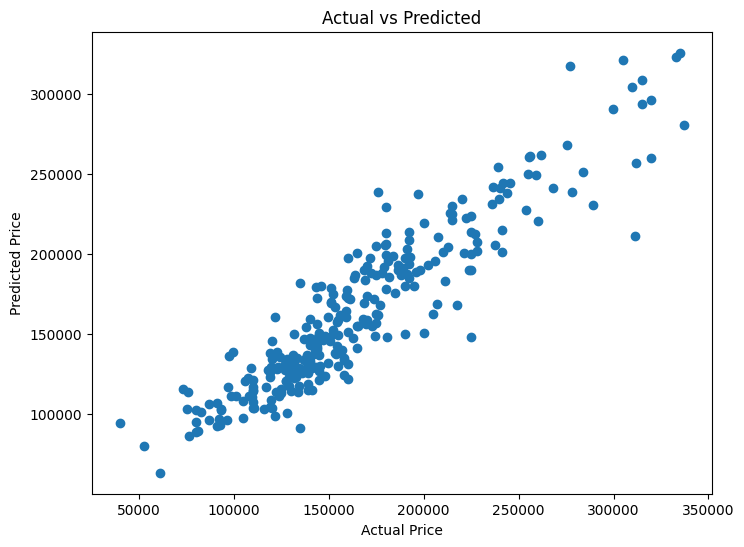

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_actual,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# RESIDUAL DISTRIBUTION

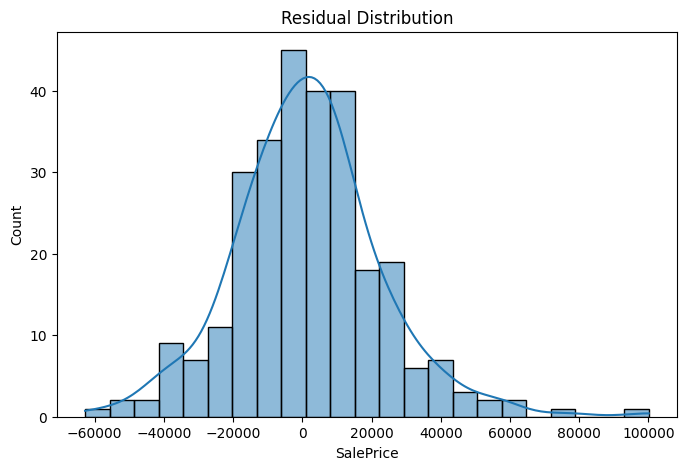

In [30]:
residuals = y_actual - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.savefig(
    "residual_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# FEATURE IMPORTANCE

In [31]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(
        model.coef_
    )
})

coef_df = coef_df.sort_values(
    by='Importance',
    ascending=False
)

print(coef_df)

         Feature  Importance
0    OverallQual    0.112305
8      YearBuilt    0.058206
9   YearRemodAdd    0.051121
2     GarageCars    0.051052
11    Fireplaces    0.047458
1      GrLivArea    0.043694
14      2ndFlrSF    0.023759
13    BsmtFinSF1    0.023665
5       1stFlrSF    0.021506
12       LotArea    0.021393
4    TotalBsmtSF    0.020202
7   TotRmsAbvGrd    0.018361
10    MasVnrArea    0.012257
3     GarageArea    0.008343
6       FullBath    0.003217


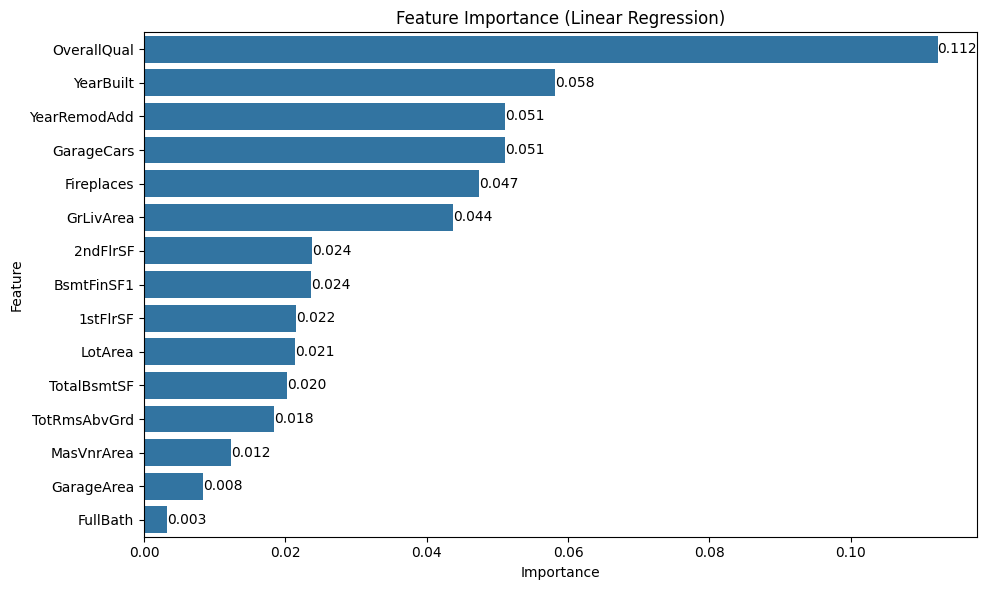

In [32]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=coef_df,
    x='Importance',
    y='Feature'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f'
    )

plt.title(
    'Feature Importance (Linear Regression)'
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# PREDICTION RESULT

In [33]:
result = pd.DataFrame({
    'Actual Price': y_actual,
    'Predicted Price': y_pred
})

result.head(10)

,Actual Price,Predicted Price
703,140000.0,142893.618502
656,145500.0,130078.130859
119,163990.0,186770.140241
502,140000.0,133379.537798
243,120000.0,145440.648260
763,337000.0,280682.257224
216,210000.0,201223.181046
913,145000.0,150508.508600
985,125000.0,115561.480365
503,289000.0,231040.795027


In [34]:
result.to_csv(
    "house_price_prediction_result.csv",
    index=False
)

print(
    "Prediction result saved successfully!"
)

Prediction result saved successfully!


# CONCLUSION

Model Linear Regression yang dibangun menunjukkan performa yang sangat baik dalam memprediksi harga rumah. Setelah dilakukan proses data cleaning, penanganan missing values, penghapusan outlier, pemilihan fitur yang relevan, serta transformasi logaritmik pada variabel target, performa model meningkat secara signifikan.

Berdasarkan hasil evaluasi, model memperoleh nilai R² sebesar 0,8560, yang menunjukkan bahwa sekitar 85,60% variasi harga rumah dapat dijelaskan oleh fitur-fitur yang digunakan dalam model. Nilai ini mengindikasikan bahwa model memiliki kemampuan prediksi yang kuat dan mampu menangkap hubungan utama antara karakteristik rumah dan harga jualnya.

Nilai MAE sebesar 15.865,26 menunjukkan bahwa rata-rata selisih antara harga prediksi dan harga aktual relatif kecil dibandingkan rentang harga rumah dalam dataset. Sementara itu, nilai RMSE sebesar 21.402,06 menunjukkan bahwa model memiliki tingkat kesalahan prediksi yang cukup rendah dan lebih stabil dibandingkan model awal sebelum dilakukan optimasi.

Analisis feature importance menunjukkan bahwa OverallQual (kualitas keseluruhan bangunan) merupakan faktor yang paling berpengaruh terhadap harga rumah, diikuti oleh GrLivArea (luas area hunian) dan beberapa fitur lain yang berkaitan dengan ukuran serta kualitas properti. Temuan ini menunjukkan bahwa kualitas bangunan dan luas area hunian merupakan faktor utama yang menentukan nilai jual sebuah rumah.

# BUSINESS INSIGHTS

Hasil analisis menunjukkan bahwa kualitas bangunan memiliki pengaruh yang lebih besar dibandingkan sekadar jumlah ruangan atau fasilitas tambahan. Rumah dengan kualitas konstruksi yang lebih baik cenderung memiliki nilai pasar yang jauh lebih tinggi dibandingkan rumah dengan spesifikasi standar.

Selain itu, luas area hunian juga menjadi faktor utama dalam menentukan harga rumah. Hal ini menunjukkan bahwa calon pembeli tidak hanya mempertimbangkan jumlah ruangan, tetapi juga kenyamanan dan luas ruang yang tersedia untuk aktivitas sehari-hari.

Bagi pengembang properti, hasil ini dapat digunakan untuk menyusun strategi pembangunan yang lebih efektif dengan memprioritaskan kualitas material, desain bangunan, dan optimalisasi luas area hunian. Fokus pada faktor-faktor tersebut berpotensi memberikan peningkatan nilai jual yang lebih tinggi dibandingkan investasi pada fitur yang memiliki pengaruh relatif kecil terhadap harga.

Secara keseluruhan, model yang dibangun telah menunjukkan performa yang baik dan dapat digunakan sebagai alat bantu dalam memperkirakan harga rumah secara objektif berdasarkan karakteristik properti yang tersedia.